# Phase 0.5: Architecture Search

## Research Questions
1. **구조**: Structure A (E[3]+θ_task[2], split) vs Structure B (mono[5], no encoder concept)
2. **θ_BS 종류/위치**: SSF vs LoRA, 어디에 붙일지 (E / θ_task / both)
3. **공유 전략**: all_except_adapter (E+θ_task shared) vs encoder_only (FedPer style) vs none (independent)
4. **기존 연구 대응**: 각 config가 어떤 기존 연구에 해당하는가?

## 23 Configurations

### Structure A (split_at=3): encoder[3 blocks] + task_head[2 blocks]

| Config | Adapter | Placement | Shared | Local | Existing Work |
|--------|---------|-----------|--------|-------|---------------|
| `A_fedavg` | none | - | all | - | FedAvg (McMahan 2017) |
| `A_fedper` | none | - | encoder only | θ_task | FedPer (Arivazhagan 2019) |
| `A_indep` | none | - | - | all | Per-BS independent |
| `A_ssf_E` | SSF | encoder | E+θ_task | SSF on E | Novel (SSF + FL) |
| `A_ssf_T` | SSF | task_head | E+θ_task | SSF on θ_task | Novel |
| `A_ssf_ET` | SSF | both | E+θ_task | SSF on all | Novel |
| `A_lora_E` | LoRA | encoder | E+θ_task | LoRA on E | pFedLoRA-like |
| `A_lora_T` | LoRA | task_head | E+θ_task | LoRA on θ_task | Novel |
| `A_lora_ET` | LoRA | both | E+θ_task | LoRA on all | FedGen-Edge-like |
| `A_ssf_E_fpE` | SSF | encoder | E only | θ_task + SSF on E | FedPer + SSF |
| `A_ssf_T_fpE` | SSF | task_head | E only | θ_task + SSF on θ_task | FedPer + SSF |
| `A_ssf_ET_fpE` | SSF | both | E only | θ_task + SSF on all | FedPer + SSF |
| `A_lora_E_fpE` | LoRA | encoder | E only | θ_task + LoRA on E | FedPerLoRA-like |
| `A_lora_T_fpE` | LoRA | task_head | E only | θ_task + LoRA on θ_task | FedPerLoRA (2025) |
| `A_lora_ET_fpE` | LoRA | both | E only | θ_task + LoRA on all | FedPerLoRA-like |
| `A_ssf_ET_ind` | SSF | both | - | all + SSF | Independent + SSF |
| `A_lora_ET_ind` | LoRA | both | - | all + LoRA | Independent + LoRA |

### Structure B (split_at=0): monolithic[5 blocks], no encoder concept

| Config | Adapter | Shared | Local | Existing Work |
|--------|---------|--------|-------|---------------|
| `B_fedavg` | none | all | - | FedAvg (= A_fedavg architecturally) |
| `B_indep` | none | - | all | Independent (= A_indep) |
| `B_ssf` | SSF on all | backbone | SSF | Novel |
| `B_ssf_ind` | SSF on all | - | all + SSF | Independent + SSF |
| `B_lora` | LoRA on all | backbone | LoRA | Novel |
| `B_lora_ind` | LoRA on all | - | all + LoRA | Independent + LoRA |

### Training
```bash
python -m src.experiments.0_baseline.train_arch_search --config all --gpus 0 1 2 3
python -m src.experiments.0_baseline.train_arch_search --config A_ssf_E B_lora --gpu 0
```

In [ ]:
import sys, os
from pathlib import Path

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import json
import numpy as np
import matplotlib.pyplot as plt

CKPT_DIR = Path(f'{PROJECT_ROOT}/assets/checkpoints/phase0_5')
ALL_BS = list(range(8))
PRETRAIN_BS = [0, 1, 2, 3, 4, 5]
TEST_BS = [6, 7]

# Structure grouping
A_CONFIGS = [n for n in sorted(os.listdir(CKPT_DIR)) if n.startswith('A_') and n.endswith('_result.json')] if CKPT_DIR.exists() else []
B_CONFIGS = [n for n in sorted(os.listdir(CKPT_DIR)) if n.startswith('B_') and n.endswith('_result.json')] if CKPT_DIR.exists() else []
print(f'Checkpoint dir: {CKPT_DIR}')
print(f'Found: {len(A_CONFIGS)} Structure A, {len(B_CONFIGS)} Structure B result files')

In [2]:
# Load all results
results = {}
for p in sorted(CKPT_DIR.glob('*_result.json')):
    with open(p) as f:
        r = json.load(f)
    results[r['config_name']] = r
    print(f"{r['config_name']:20s}: avg={r['avg_nmse_db']:.2f}, "
          f"pretrain={r['avg_pretrain_bs']:.2f}, test={r['avg_test_bs']:.2f}, "
          f"shared={r['n_shared_params']}, local={r['n_local_params']}, "
          f"adapter={r['n_adapter_params']}")

print(f'\nLoaded {len(results)} configs')
A_names = [n for n in results if n.startswith('A_')]
B_names = [n for n in results if n.startswith('B_')]
print(f'  Structure A: {len(A_names)}, Structure B: {len(B_names)}')

A_fedavg_c128       : avg=-18.78, pretrain=-19.30, test=-17.24, shared=1483394, local=0, adapter=0
A_fedavg_dws        : avg=-15.41, pretrain=-15.62, test=-14.79, shared=51778, local=0, adapter=0
A_fedavg            : avg=-17.04, pretrain=-17.31, test=-16.23, shared=373058, local=0, adapter=0
A_fedavg_se         : avg=-18.04, pretrain=-18.39, test=-16.99, shared=383698, local=0, adapter=0
A_fedper            : avg=-17.27, pretrain=-17.59, test=-16.29, shared=223164, local=149894, adapter=0
A_indep_c128        : avg=-21.02, pretrain=-21.66, test=-19.11, shared=-2827, local=1486221, adapter=0
A_indep_dws         : avg=-15.53, pretrain=-15.67, test=-15.09, shared=-1419, local=53197, adapter=0
A_indep             : avg=-17.85, pretrain=-18.10, test=-17.10, shared=-1419, local=374477, adapter=0
A_indep_se          : avg=-19.10, pretrain=-19.35, test=-18.34, shared=-1419, local=385117, adapter=0
A_lora_ET_fpE       : avg=-18.01, pretrain=-18.15, test=-17.59, shared=223164, local=175494, adap

## 1. Overall Comparison (All 23 configs)

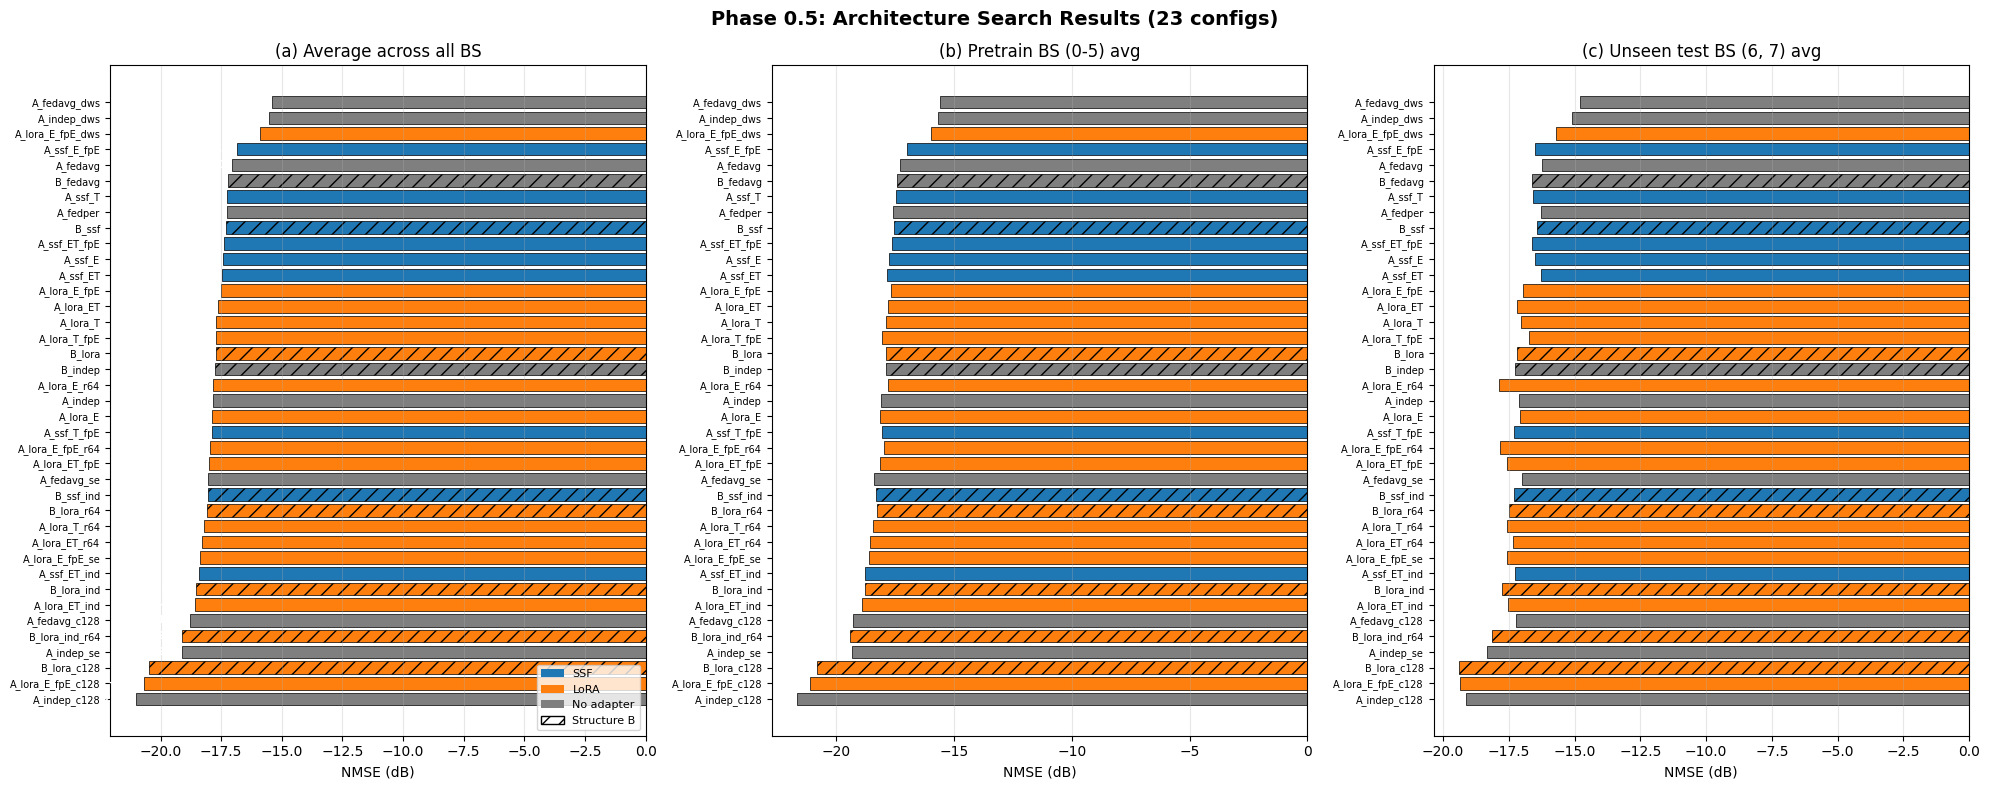

In [3]:
if results:
    # Sort by avg NMSE (lower = better)
    sorted_names = sorted(results.keys(), key=lambda n: results[n]['avg_nmse_db'])

    fig, axes = plt.subplots(1, 3, figsize=(20, 8))

    def _color(n):
        if 'ssf' in n: return 'C0'
        if 'lora' in n: return 'C1'
        return 'C7'

    def _hatch(n):
        """Structure B gets hatching."""
        return '//' if n.startswith('B_') else None

    # (a) Average NMSE
    ax = axes[0]
    vals = [results[n]['avg_nmse_db'] for n in sorted_names]
    colors = [_color(n) for n in sorted_names]
    hatches = [_hatch(n) for n in sorted_names]
    bars = ax.barh(range(len(sorted_names)), vals, color=colors, edgecolor='black', linewidth=0.5)
    for bar, h in zip(bars, hatches):
        bar.set_hatch(h)
    ax.set_yticks(range(len(sorted_names)))
    ax.set_yticklabels(sorted_names, fontsize=7)
    ax.set_xlabel('NMSE (dB)')
    ax.set_title('(a) Average across all BS')
    ax.grid(True, alpha=0.3, axis='x')
    for bar, v in zip(bars, vals):
        ax.text(v - 0.3, bar.get_y() + bar.get_height()/2, f'{v:.1f}',
                va='center', ha='right', fontsize=7, fontweight='bold', color='white')

    # (b) Pretrain BS avg
    ax = axes[1]
    vals = [results[n]['avg_pretrain_bs'] for n in sorted_names]
    bars = ax.barh(range(len(sorted_names)), vals, color=colors, edgecolor='black', linewidth=0.5)
    for bar, h in zip(bars, hatches):
        bar.set_hatch(h)
    ax.set_yticks(range(len(sorted_names)))
    ax.set_yticklabels(sorted_names, fontsize=7)
    ax.set_xlabel('NMSE (dB)')
    ax.set_title('(b) Pretrain BS (0-5) avg')
    ax.grid(True, alpha=0.3, axis='x')

    # (c) Test BS avg
    ax = axes[2]
    vals = [results[n]['avg_test_bs'] for n in sorted_names]
    bars = ax.barh(range(len(sorted_names)), vals, color=colors, edgecolor='black', linewidth=0.5)
    for bar, h in zip(bars, hatches):
        bar.set_hatch(h)
    ax.set_yticks(range(len(sorted_names)))
    ax.set_yticklabels(sorted_names, fontsize=7)
    ax.set_xlabel('NMSE (dB)')
    ax.set_title('(c) Unseen test BS (6, 7) avg')
    ax.grid(True, alpha=0.3, axis='x')

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='C0', label='SSF'),
        Patch(facecolor='C1', label='LoRA'),
        Patch(facecolor='C7', label='No adapter'),
        Patch(facecolor='white', edgecolor='black', hatch='//', label='Structure B'),
    ]
    axes[0].legend(handles=legend_elements, loc='lower right', fontsize=8)

    plt.suptitle('Phase 0.5: Architecture Search Results (23 configs)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No results found. Run phase0_5_train.py first.')

## 2. Q0: Structure A vs Structure B

Structure A (split_at=3): encoder + task_head 분리 → adapter 위치 선택 가능
Structure B (split_at=0): 단일 네트워크 → encoder 개념 없음, adapter는 전체에만

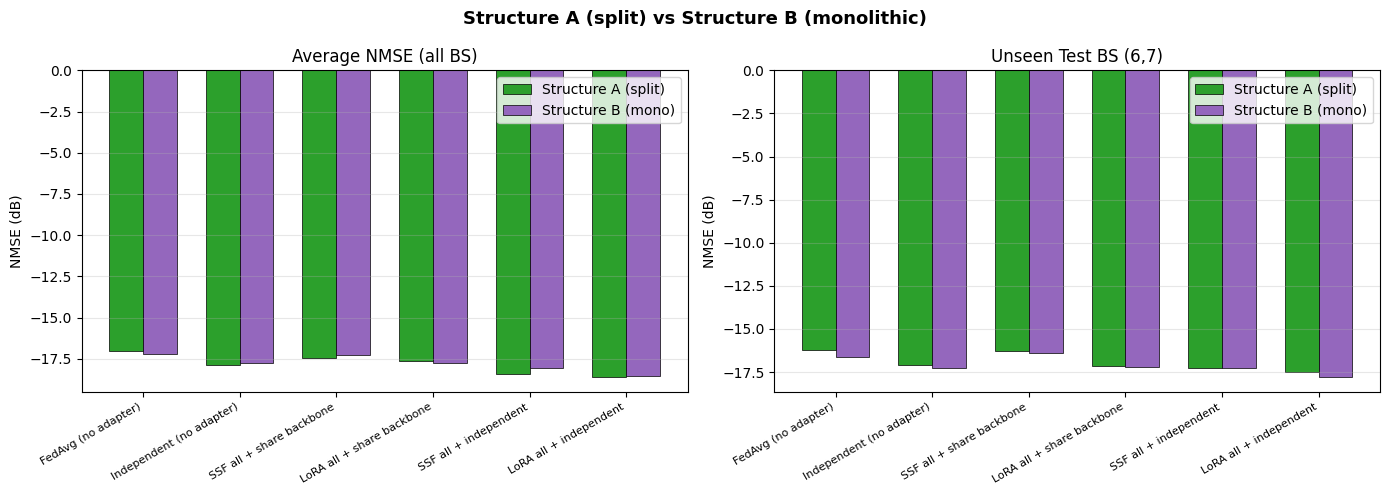


Structure A vs B (matched pairs):
  FedAvg (no adapter)                : A=-17.04, B=-17.23, winner=B by 0.19 dB
  Independent (no adapter)           : A=-17.85, B=-17.75, winner=A by 0.10 dB
  SSF all + share backbone           : A=-17.45, B=-17.28, winner=A by 0.16 dB
  LoRA all + share backbone          : A=-17.64, B=-17.73, winner=B by 0.09 dB
  SSF all + independent              : A=-18.42, B=-18.06, winner=A by 0.36 dB
  LoRA all + independent             : A=-18.58, B=-18.52, winner=A by 0.06 dB


In [4]:
# Structure A vs B: matched comparisons
# A_fedavg ≡ B_fedavg (architecturally identical), A_indep ≡ B_indep
# Compare: A_ssf_ET vs B_ssf, A_lora_ET vs B_lora (same adapter on all blocks, same sharing)
# Compare: A_ssf_ET_ind vs B_ssf_ind, A_lora_ET_ind vs B_lora_ind (independent + adapter)

pairs = [
    ('A_fedavg', 'B_fedavg', 'FedAvg (no adapter)'),
    ('A_indep', 'B_indep', 'Independent (no adapter)'),
    ('A_ssf_ET', 'B_ssf', 'SSF all + share backbone'),
    ('A_lora_ET', 'B_lora', 'LoRA all + share backbone'),
    ('A_ssf_ET_ind', 'B_ssf_ind', 'SSF all + independent'),
    ('A_lora_ET_ind', 'B_lora_ind', 'LoRA all + independent'),
]

available_pairs = [(a, b, label) for a, b, label in pairs if a in results and b in results]

if available_pairs:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(available_pairs))
    width = 0.35

    for ax_idx, (metric, title) in enumerate([
        ('avg_nmse_db', 'Average NMSE (all BS)'),
        ('avg_test_bs', 'Unseen Test BS (6,7)')
    ]):
        ax = axes[ax_idx]
        a_vals = [results[a][metric] for a, b, _ in available_pairs]
        b_vals = [results[b][metric] for a, b, _ in available_pairs]
        labels = [label for _, _, label in available_pairs]

        ax.bar(x - width/2, a_vals, width, label='Structure A (split)', color='C2', edgecolor='black', linewidth=0.5)
        ax.bar(x + width/2, b_vals, width, label='Structure B (mono)', color='C4', edgecolor='black', linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
        ax.set_ylabel('NMSE (dB)')
        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('Structure A (split) vs Structure B (monolithic)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print summary
    print('\nStructure A vs B (matched pairs):')
    for a_name, b_name, label in available_pairs:
        diff = results[a_name]['avg_nmse_db'] - results[b_name]['avg_nmse_db']
        winner = 'A' if diff < 0 else 'B'
        print(f'  {label:35s}: A={results[a_name]["avg_nmse_db"]:.2f}, '
              f'B={results[b_name]["avg_nmse_db"]:.2f}, winner={winner} by {abs(diff):.2f} dB')
else:
    print('No matched A/B pairs found yet.')

## 3. Q1: Adapter Placement — E vs θ_task vs Both (Structure A only)

Structure A에서만 의미 있음 (B는 encoder 개념 없으므로 항상 all)

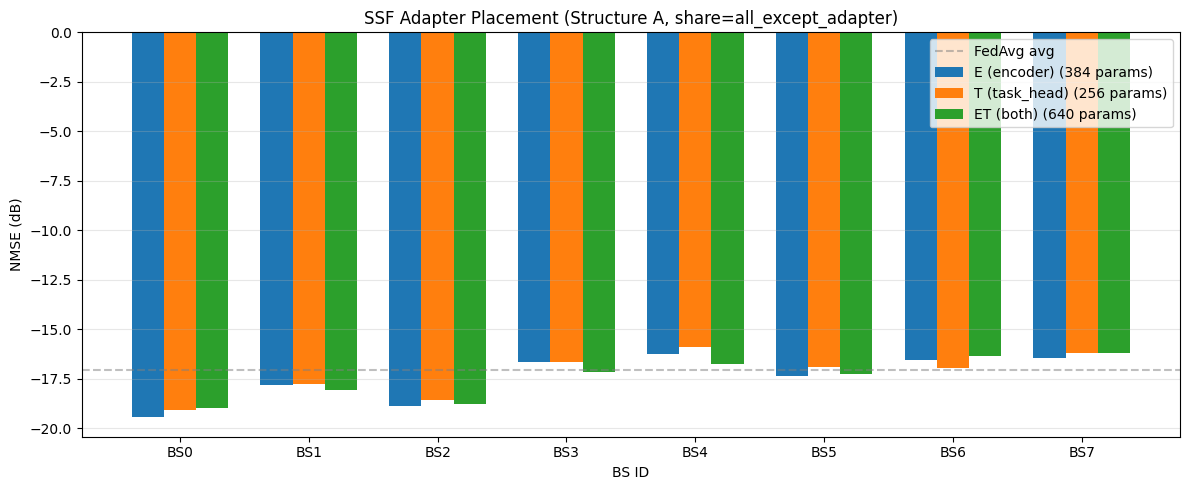

  A_ssf_E              (E (encoder) ): avg=-17.44, test=-16.51, adapter_params=384
  A_ssf_T              (T (task_head)): avg=-17.25, test=-16.57, adapter_params=256
  A_ssf_ET             (ET (both)   ): avg=-17.45, test=-16.29, adapter_params=640


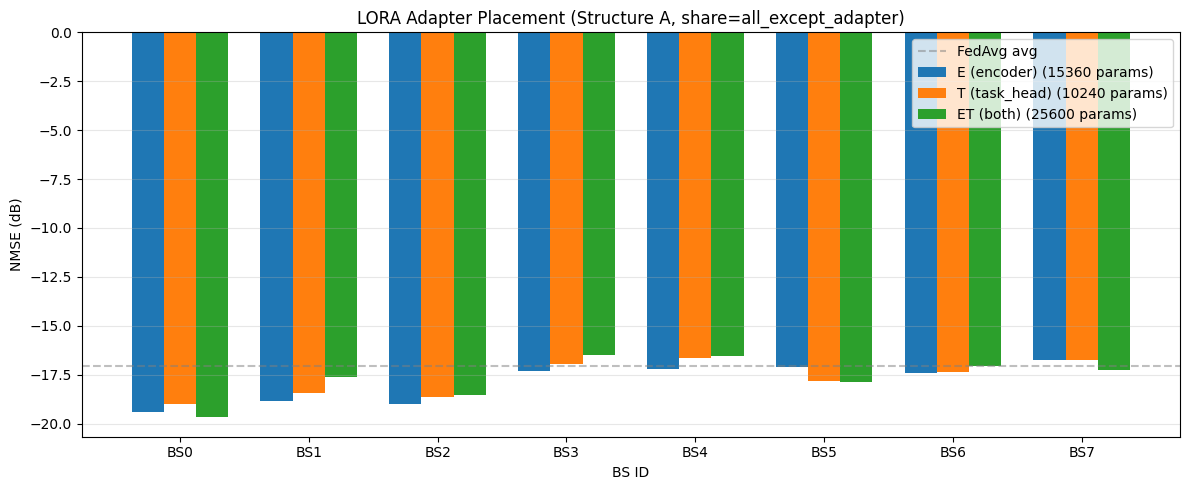

  A_lora_E             (E (encoder) ): avg=-17.87, test=-17.06, adapter_params=15360
  A_lora_T             (T (task_head)): avg=-17.70, test=-17.04, adapter_params=10240
  A_lora_ET            (ET (both)   ): avg=-17.64, test=-17.17, adapter_params=25600

--- FedPer-style (encoder_only) sharing ---
  A_ssf_E_fpE         : avg=-16.87, test=-16.52, local=150278
  A_ssf_T_fpE         : avg=-17.89, test=-17.30, local=150150
  A_ssf_ET_fpE        : avg=-17.39, test=-16.60, local=150534
  A_lora_E_fpE        : avg=-17.50, test=-16.97, local=165254
  A_lora_T_fpE        : avg=-17.72, test=-16.74, local=160134
  A_lora_ET_fpE       : avg=-18.01, test=-17.59, local=175494


In [5]:
# Compare placement for each adapter type (Structure A, share=all_except_adapter)
for atype in ['ssf', 'lora']:
    placements = {
        'E (encoder)': f'A_{atype}_E',
        'T (task_head)': f'A_{atype}_T',
        'ET (both)': f'A_{atype}_ET',
    }
    available = {label: name for label, name in placements.items() if name in results}
    if not available:
        continue

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(ALL_BS))
    width = 0.25
    for i, (label, name) in enumerate(available.items()):
        vals = [results[name]['final_nmse_db'][str(bs)] for bs in ALL_BS]
        ax.bar(x + i * width, vals, width, label=f'{label} ({results[name]["n_adapter_params"]} params)')

    # Add baselines
    if 'A_fedavg' in results:
        ax.axhline(y=results['A_fedavg']['avg_nmse_db'], color='gray',
                    linestyle='--', alpha=0.5, label='FedAvg avg')

    ax.set_xlabel('BS ID')
    ax.set_ylabel('NMSE (dB)')
    ax.set_title(f'{atype.upper()} Adapter Placement (Structure A, share=all_except_adapter)')
    ax.set_xticks(x + width)
    ax.set_xticklabels([f'BS{i}' for i in ALL_BS])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    for label, name in available.items():
        r = results[name]
        print(f"  {name:20s} ({label:12s}): avg={r['avg_nmse_db']:.2f}, "
              f"test={r['avg_test_bs']:.2f}, adapter_params={r['n_adapter_params']}")

# Same for FedPer-style sharing (encoder_only)
print('\n--- FedPer-style (encoder_only) sharing ---')
for atype in ['ssf', 'lora']:
    for suffix, label in [('E_fpE', 'E'), ('T_fpE', 'T'), ('ET_fpE', 'ET')]:
        name = f'A_{atype}_{suffix}'
        if name in results:
            r = results[name]
            print(f"  {name:20s}: avg={r['avg_nmse_db']:.2f}, "
                  f"test={r['avg_test_bs']:.2f}, local={r['n_local_params']}")

## 4. Q2: SSF vs LoRA (same placement, same sharing)

Description                    |   SSF (dB)   params |  LoRA (dB)   params | Winner      Δ | LoRA/SSF
---------------------------------------------------------------------------------------------------------
A / E / share all              |     -17.44      384 |     -17.87    15360 |   LoRA  0.43 |    40.0x
A / T / share all              |     -17.25      256 |     -17.70    10240 |   LoRA  0.45 |    40.0x
A / ET / share all             |     -17.45      640 |     -17.64    25600 |   LoRA  0.19 |    40.0x
A / E / FedPer                 |     -16.87      384 |     -17.50    15360 |   LoRA  0.63 |    40.0x
A / T / FedPer                 |     -17.89      256 |     -17.72    10240 |    SSF  0.17 |    40.0x
A / ET / FedPer                |     -17.39      640 |     -18.01    25600 |   LoRA  0.62 |    40.0x
A / ET / independent           |     -18.42      640 |     -18.58    25600 |   LoRA  0.15 |    40.0x
B / all / share backbone       |     -17.28      640 |     -17.73    25600 |   LoRA  

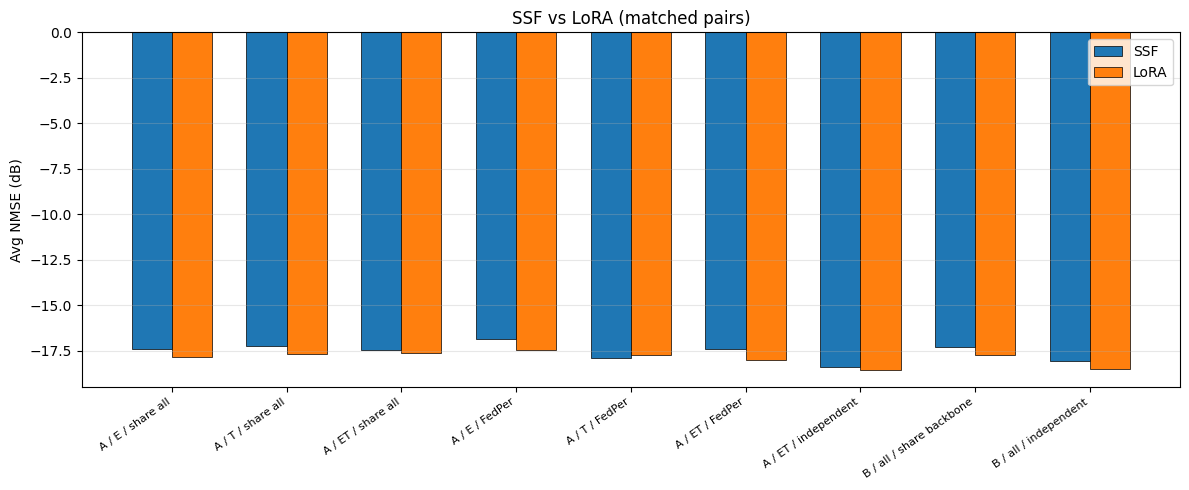

In [6]:
# SSF vs LoRA: matched pairs (same placement + same sharing)
ssf_lora_pairs = [
    # (ssf_name, lora_name, description)
    # share=all_except_adapter
    ('A_ssf_E', 'A_lora_E', 'A / E / share all'),
    ('A_ssf_T', 'A_lora_T', 'A / T / share all'),
    ('A_ssf_ET', 'A_lora_ET', 'A / ET / share all'),
    # share=encoder_only
    ('A_ssf_E_fpE', 'A_lora_E_fpE', 'A / E / FedPer'),
    ('A_ssf_T_fpE', 'A_lora_T_fpE', 'A / T / FedPer'),
    ('A_ssf_ET_fpE', 'A_lora_ET_fpE', 'A / ET / FedPer'),
    # share=none (independent)
    ('A_ssf_ET_ind', 'A_lora_ET_ind', 'A / ET / independent'),
    # Structure B
    ('B_ssf', 'B_lora', 'B / all / share backbone'),
    ('B_ssf_ind', 'B_lora_ind', 'B / all / independent'),
]

available = [(s, l, desc) for s, l, desc in ssf_lora_pairs if s in results and l in results]

if available:
    print(f'{"Description":30s} | {"SSF (dB)":>10s} {"params":>8s} | {"LoRA (dB)":>10s} {"params":>8s} | {"Winner":>6s} {"Δ":>6s} | {"LoRA/SSF":>8s}')
    print('-' * 105)
    for ssf_name, lora_name, desc in available:
        s, l = results[ssf_name], results[lora_name]
        diff = s['avg_nmse_db'] - l['avg_nmse_db']
        winner = 'SSF' if diff < 0 else 'LoRA'
        ratio = l['n_adapter_params'] / max(s['n_adapter_params'], 1)
        print(f'{desc:30s} | {s["avg_nmse_db"]:>10.2f} {s["n_adapter_params"]:>8d} | '
              f'{l["avg_nmse_db"]:>10.2f} {l["n_adapter_params"]:>8d} | '
              f'{winner:>6s} {abs(diff):>5.2f} | {ratio:>7.1f}x')

    # Bar chart
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(available))
    width = 0.35
    ssf_vals = [results[s]['avg_nmse_db'] for s, _, _ in available]
    lora_vals = [results[l]['avg_nmse_db'] for _, l, _ in available]
    labels = [desc for _, _, desc in available]

    ax.bar(x - width/2, ssf_vals, width, label='SSF', color='C0', edgecolor='black', linewidth=0.5)
    ax.bar(x + width/2, lora_vals, width, label='LoRA', color='C1', edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Avg NMSE (dB)')
    ax.set_title('SSF vs LoRA (matched pairs)')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print('No SSF/LoRA pairs available yet.')

## 5. Q3: Sharing Strategy — all_except_adapter vs encoder_only vs none


--- SSF on both (ET) ---
  Share E+θ_task            (A_ssf_ET            ): avg=-17.45, test=-16.29, shared=373058, local=640
  Share E only (FedPer)     (A_ssf_ET_fpE        ): avg=-17.39, test=-16.60, shared=223164, local=150534
  Independent               (A_ssf_ET_ind        ): avg=-18.42, test=-17.28, shared=-1419, local=375117

--- LORA on both (ET) ---
  Share E+θ_task            (A_lora_ET           ): avg=-17.64, test=-17.17, shared=373058, local=25600
  Share E only (FedPer)     (A_lora_ET_fpE       ): avg=-18.01, test=-17.59, shared=223164, local=175494
  Independent               (A_lora_ET_ind       ): avg=-18.58, test=-17.51, shared=-1419, local=400077

--- Baselines (no adapter) ---
  FedAvg (share all)        (A_fedavg            ): avg=-17.04, test=-16.23, shared=373058, local=0
  FedPer (share E only)     (A_fedper            ): avg=-17.27, test=-16.29, shared=223164, local=149894
  Independent               (A_indep             ): avg=-17.85, test=-17.10, shared=-1

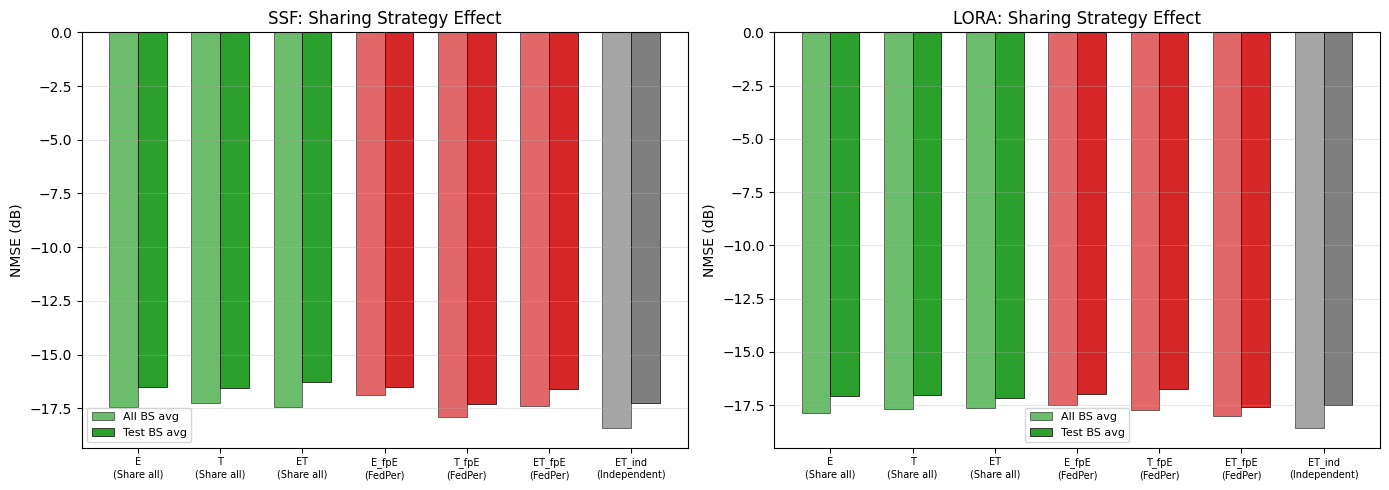

In [7]:
# Sharing strategy comparison: 3 levels for each adapter type
# For Structure A with adapter on both (ET): share all vs FedPer vs independent
for atype in ['ssf', 'lora']:
    share_all = f'A_{atype}_ET'       # share E+θ_task, adapter local
    share_enc = f'A_{atype}_ET_fpE'   # share E only, θ_task+adapter local
    share_none = f'A_{atype}_ET_ind'  # share nothing, everything local

    configs = [
        (share_all, 'Share E+θ_task'),
        (share_enc, 'Share E only (FedPer)'),
        (share_none, 'Independent'),
    ]
    available = [(n, label) for n, label in configs if n in results]
    if len(available) < 2:
        continue

    print(f'\n--- {atype.upper()} on both (ET) ---')
    for name, label in available:
        r = results[name]
        print(f'  {label:25s} ({name:20s}): avg={r["avg_nmse_db"]:.2f}, '
              f'test={r["avg_test_bs"]:.2f}, shared={r["n_shared_params"]}, local={r["n_local_params"]}')

# Baselines (no adapter) comparison
print('\n--- Baselines (no adapter) ---')
for name, label in [('A_fedavg', 'FedAvg (share all)'),
                     ('A_fedper', 'FedPer (share E only)'),
                     ('A_indep', 'Independent')]:
    if name in results:
        r = results[name]
        print(f'  {label:25s} ({name:20s}): avg={r["avg_nmse_db"]:.2f}, '
              f'test={r["avg_test_bs"]:.2f}, shared={r["n_shared_params"]}, local={r["n_local_params"]}')

# Grouped bar chart: sharing strategy effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, atype in enumerate(['ssf', 'lora']):
    ax = axes[ax_idx]
    groups = {
        'Share all': [f'A_{atype}_E', f'A_{atype}_T', f'A_{atype}_ET'],
        'FedPer': [f'A_{atype}_E_fpE', f'A_{atype}_T_fpE', f'A_{atype}_ET_fpE'],
        'Independent': [f'A_{atype}_ET_ind'],
    }
    x_labels, x_vals_avg, x_vals_test = [], [], []
    colors = []
    color_map = {'Share all': 'C2', 'FedPer': 'C3', 'Independent': 'C7'}

    for group_name, names in groups.items():
        for name in names:
            if name in results:
                short = name.replace(f'A_{atype}_', '')
                x_labels.append(f'{short}\n({group_name})')
                x_vals_avg.append(results[name]['avg_nmse_db'])
                x_vals_test.append(results[name]['avg_test_bs'])
                colors.append(color_map[group_name])

    if x_labels:
        x = np.arange(len(x_labels))
        width = 0.35
        ax.bar(x - width/2, x_vals_avg, width, label='All BS avg', color=colors, edgecolor='black', linewidth=0.5, alpha=0.7)
        ax.bar(x + width/2, x_vals_test, width, label='Test BS avg', color=colors, edgecolor='black', linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, fontsize=7)
        ax.set_ylabel('NMSE (dB)')
        ax.set_title(f'{atype.upper()}: Sharing Strategy Effect')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. FL Convergence Curves

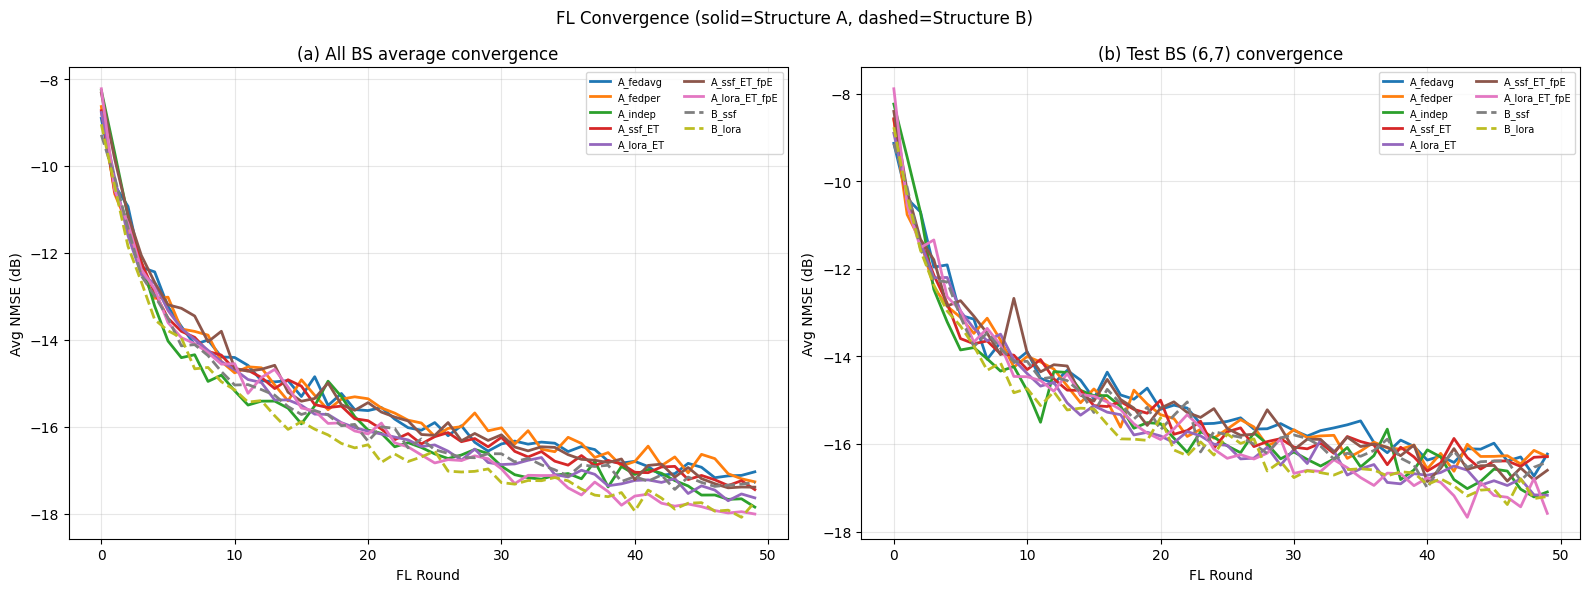

In [8]:
# Plot convergence for key configs (representative from each category)
key_configs = [
    'A_fedavg', 'A_fedper', 'A_indep',          # baselines
    'A_ssf_ET', 'A_lora_ET',                     # adapter + share all
    'A_ssf_ET_fpE', 'A_lora_ET_fpE',             # adapter + FedPer
    'B_ssf', 'B_lora',                            # Structure B
]
available = [n for n in key_configs if n in results and 'history' in results[n]]

if available:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # (a) All BS average
    ax = axes[0]
    for name in available:
        hist = results[name]['history']
        rounds = hist['round']
        avg_per_round = [
            np.mean([hist['val_nmse_db'][str(bs)][r] for bs in ALL_BS])
            for r in range(len(rounds))
        ]
        style = '--' if name.startswith('B_') else '-'
        ax.plot(rounds, avg_per_round, style, label=name, linewidth=2)
    ax.set_xlabel('FL Round')
    ax.set_ylabel('Avg NMSE (dB)')
    ax.set_title('(a) All BS average convergence')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

    # (b) Test BS only
    ax = axes[1]
    for name in available:
        hist = results[name]['history']
        rounds = hist['round']
        test_per_round = [
            np.mean([hist['val_nmse_db'][str(bs)][r] for bs in TEST_BS])
            for r in range(len(rounds))
        ]
        style = '--' if name.startswith('B_') else '-'
        ax.plot(rounds, test_per_round, style, label=name, linewidth=2)
    ax.set_xlabel('FL Round')
    ax.set_ylabel('Avg NMSE (dB)')
    ax.set_title('(b) Test BS (6,7) convergence')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

    plt.suptitle('FL Convergence (solid=Structure A, dashed=Structure B)', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('No convergence data available yet.')

## 8. Decision Summary

### Q0: Structure A (split) vs Structure B (monolithic)
- A_fedavg ≡ B_fedavg, A_indep ≡ B_indep (아키텍처 동일, split_at만 다름)
- A_ssf_ET vs B_ssf, A_lora_ET vs B_lora: adapter도 같은 블록에 붙음 → 사실상 동일
- **차이점**: Structure A는 placement 축(E/T/ET)과 encoder_only 공유 전략이 추가됨
- **결론**: (결과 보고 작성) — A가 flexibility 제공, B와 성능 차이 있는지?

### Q1: Adapter Placement (Structure A only)
- E (encoder only) vs T (task_head only) vs ET (both)
- E: encoder를 site-specific하게 → feature extraction 단계에서 적응
- T: task head를 site-specific하게 → decoder 단계에서 적응
- ET: 전체에 adapter → 가장 많은 adapter params
- **결론**: (결과 보고 작성)

### Q2: SSF vs LoRA
- 같은 placement, 같은 sharing에서 9개 matched pair 비교
- SSF: 128 params/block (scale+shift), mergeable → few-shot에 유리할 가능성
- LoRA: 5120 params/block (rank=8), stronger adaptation → FL 성능에 유리할 가능성
- **결론**: (결과 보고 작성)

### Q3: Sharing Strategy
- all_except_adapter: E+θ_task 공유, adapter만 local → 최대 일반화
- encoder_only (FedPer): E만 공유, θ_task+adapter local → personalization 강화
- none (independent): 공유 안 함 → baseline
- **결론**: (결과 보고 작성)

### Selected Architecture for Phase 1+
- **Structure**: (A or B)
- **Adapter type**: (SSF or LoRA)
- **Placement**: (E / T / ET)
- **Sharing**: (all_except_adapter / encoder_only)
- **Rationale**: (결과 기반)

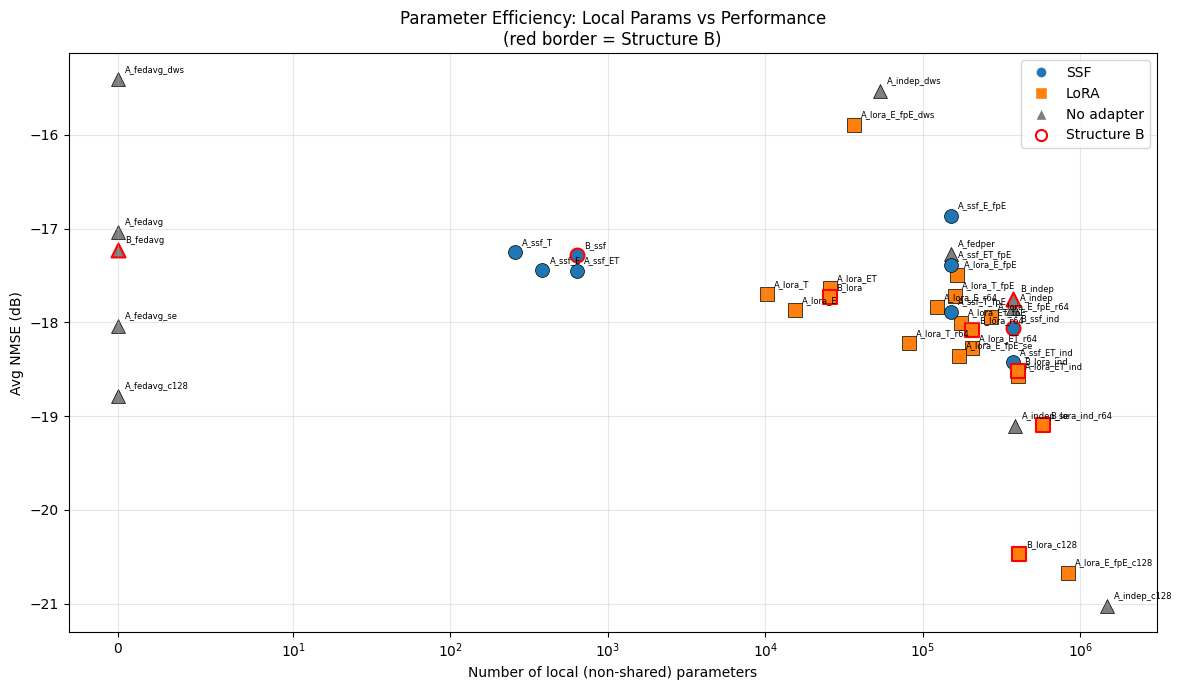

In [9]:
if results:
    fig, ax = plt.subplots(figsize=(12, 7))
    for name, r in results.items():
        color = 'C0' if 'ssf' in name else 'C1' if 'lora' in name else 'C7'
        marker = 'o' if 'ssf' in name else 's' if 'lora' in name else '^'
        edge = 'red' if name.startswith('B_') else 'black'
        ax.scatter(r['n_local_params'], r['avg_nmse_db'],
                   c=color, marker=marker, s=100, edgecolors=edge, linewidth=1.5 if name.startswith('B_') else 0.5)
        ax.annotate(name, (r['n_local_params'], r['avg_nmse_db']),
                    textcoords='offset points', xytext=(5, 5), fontsize=6)

    ax.set_xlabel('Number of local (non-shared) parameters')
    ax.set_ylabel('Avg NMSE (dB)')
    ax.set_title('Parameter Efficiency: Local Params vs Performance\n(red border = Structure B)')
    ax.set_xscale('symlog', linthresh=10)
    ax.grid(True, alpha=0.3)

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='C0', markersize=8, label='SSF'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='C1', markersize=8, label='LoRA'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='C7', markersize=8, label='No adapter'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor='red',
               markersize=8, markeredgewidth=1.5, label='Structure B'),
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    plt.tight_layout()
    plt.show()

## 7. Backbone-Agnostic Validation

ResNet / PACE-Net / DWS-ResNet 각각에서 FedAvg, Independent, Ours (LoRA+FedPer) 비교.
- On-device (O-DU) 환경에서는 DWS-ResNet (52K params) 수준이 현실적
- 모델 capacity가 제한적일수록 collaborative learning의 이점이 큼

Backbone     Method                 Params   Avg dB  Pretrain  Test dB  Adapter
--------------------------------------------------------------------------------
ResNet       FedAvg                373,058   -17.04    -17.31   -16.23        0
ResNet       Independent           373,058   -17.85    -18.10   -17.10        0
ResNet       Ours (LoRA+FedPer)    388,418   -17.50    -17.67   -16.97   15,360

PACE-Net    FedAvg                383,698   -18.04    -18.39   -16.99        0
PACE-Net    Independent           383,698   -19.10    -19.35   -18.34        0
PACE-Net    Ours (LoRA+FedPer)    399,058   -18.36    -18.62   -17.58   15,360

DWS-ResNet   FedAvg                 51,778   -15.41    -15.62   -14.79        0
DWS-ResNet   Independent            51,778   -15.53    -15.67   -15.09        0
DWS-ResNet   Ours (LoRA+FedPer)     67,138   -15.90    -15.97   -15.70   15,360



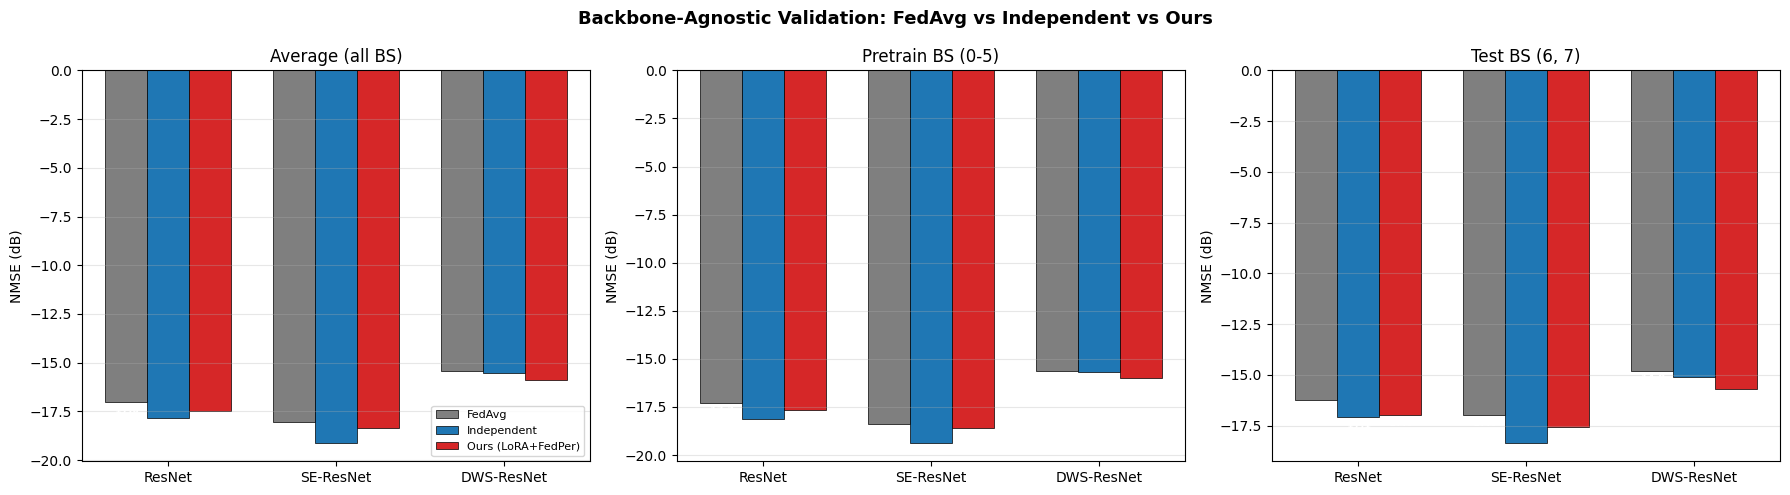


=== Ours vs Independent (Test BS) ===
  ResNet      : Ours=-16.97, Indep=-17.10, delta=+0.12 dB (Indep), params=388,418
  PACE-Net   : Ours=-17.58, Indep=-18.34, delta=+0.77 dB (Indep), params=399,058
  DWS-ResNet  : Ours=-15.70, Indep=-15.09, delta=-0.60 dB (Ours), params=67,138


In [10]:
# Backbone comparison: ResNet vs PACE-Net vs DWS-ResNet
backbone_configs = {
    'ResNet': {'fedavg': 'A_fedavg', 'indep': 'A_indep', 'ours': 'A_lora_E_fpE'},
    'PACE-Net': {'fedavg': 'A_fedavg_se', 'indep': 'A_indep_se', 'ours': 'A_lora_E_fpE_se'},
    'DWS-ResNet': {'fedavg': 'A_fedavg_dws', 'indep': 'A_indep_dws', 'ours': 'A_lora_E_fpE_dws'},
}

# Check availability
available_bb = {}
for bb_name, cfgs in backbone_configs.items():
    if all(c in results for c in cfgs.values()):
        available_bb[bb_name] = cfgs

if available_bb:
    # Summary table
    print(f"{'Backbone':<12} {'Method':<20} {'Params':>8} {'Avg dB':>8} {'Pretrain':>9} {'Test dB':>8} {'Adapter':>8}")
    print('-' * 80)
    for bb_name, cfgs in available_bb.items():
        for method, cfg_name in cfgs.items():
            r = results[cfg_name]
            label = {'fedavg': 'FedAvg', 'indep': 'Independent', 'ours': 'Ours (LoRA+FedPer)'}[method]
            print(f'{bb_name:<12} {label:<20} {r["n_total_params"]:>8,} {r["avg_nmse_db"]:>8.2f} '
                  f'{r["avg_pretrain_bs"]:>9.2f} {r["avg_test_bs"]:>8.2f} {r["n_adapter_params"]:>8,}')
        print()

    # Bar chart: 3 backbones × 3 methods
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    method_colors = {'fedavg': 'C7', 'indep': 'C0', 'ours': 'C3'}
    method_labels = {'fedavg': 'FedAvg', 'indep': 'Independent', 'ours': 'Ours (LoRA+FedPer)'}

    for ax_idx, (metric, title) in enumerate([
        ('avg_nmse_db', 'Average (all BS)'),
        ('avg_pretrain_bs', 'Pretrain BS (0-5)'),
        ('avg_test_bs', 'Test BS (6, 7)'),
    ]):
        ax = axes[ax_idx]
        x = np.arange(len(available_bb))
        width = 0.25
        for i, (method, color) in enumerate(method_colors.items()):
            vals = [results[cfgs[method]][metric] for cfgs in available_bb.values()]
            bars = ax.bar(x + i * width, vals, width, label=method_labels[method],
                         color=color, edgecolor='black', linewidth=0.5)
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width()/2, v - 0.15, f'{v:.1f}',
                        ha='center', va='top', fontsize=7, fontweight='bold', color='white')
        ax.set_xticks(x + width)
        ax.set_xticklabels(list(available_bb.keys()))
        ax.set_ylabel('NMSE (dB)')
        ax.set_title(title)
        if ax_idx == 0:
            ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('Backbone-Agnostic Validation: FedAvg vs Independent vs Ours', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Ours vs Independent gap per backbone
    print('\n=== Ours vs Independent (Test BS) ===')
    for bb_name, cfgs in available_bb.items():
        ours_test = results[cfgs['ours']]['avg_test_bs']
        indep_test = results[cfgs['indep']]['avg_test_bs']
        delta = ours_test - indep_test
        params = results[cfgs['ours']]['n_total_params']
        winner = 'Ours' if delta < 0 else 'Indep'
        print(f'  {bb_name:<12}: Ours={ours_test:.2f}, Indep={indep_test:.2f}, '
              f'delta={delta:+.2f} dB ({winner}), params={params:,}')
else:
    print('Backbone comparison results not available yet. Run:'
          '\n  python -m src.experiments.0_baseline.train_arch_search --config A_fedavg_se A_indep_se A_lora_E_fpE_se A_fedavg_dws A_indep_dws A_lora_E_fpE_dws --gpus 1 2 3 4 5 6')

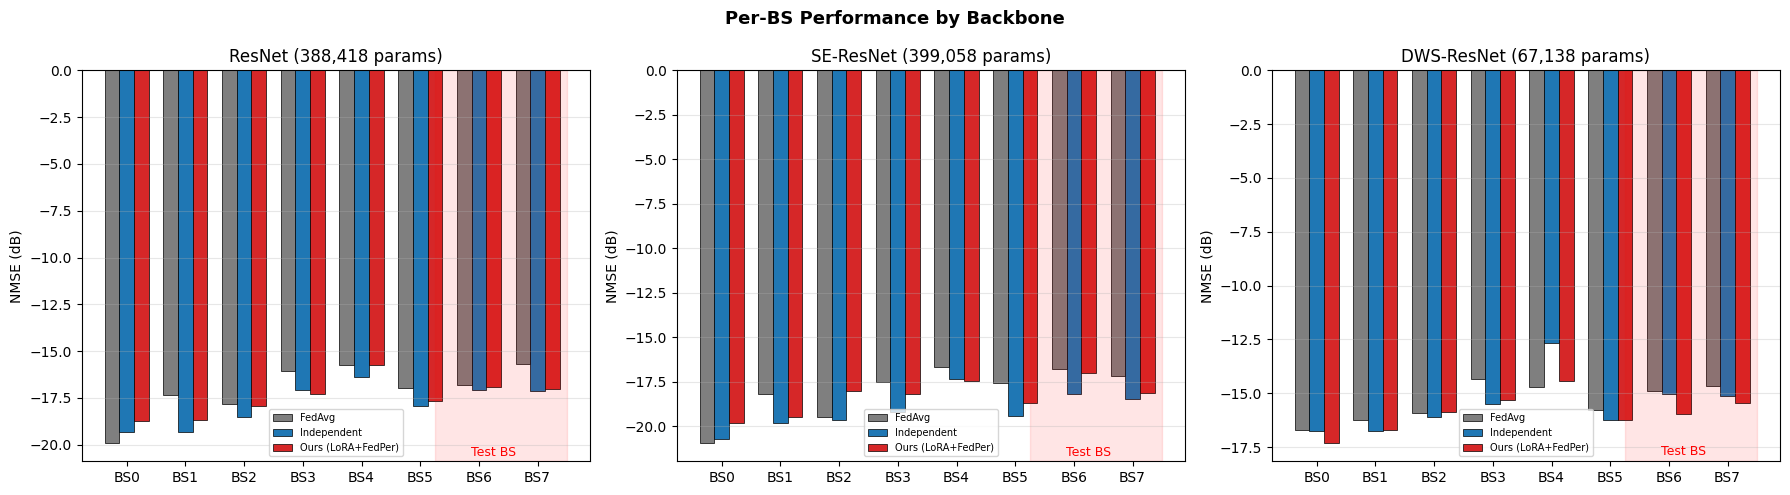

In [11]:
# Per-BS breakdown for each backbone (test BS highlighted)
if available_bb:
    fig, axes = plt.subplots(1, len(available_bb), figsize=(6 * len(available_bb), 5))
    if len(available_bb) == 1:
        axes = [axes]

    for ax, (bb_name, cfgs) in zip(axes, available_bb.items()):
        x = np.arange(len(ALL_BS))
        width = 0.25
        for i, (method, color) in enumerate(method_colors.items()):
            r = results[cfgs[method]]
            vals = [r['final_nmse_db'][str(bs)] for bs in ALL_BS]
            ax.bar(x + i * width, vals, width, label=method_labels[method],
                   color=color, edgecolor='black', linewidth=0.5)

        # Highlight test BS
        ax.axvspan(5.5, 7.5 + width, alpha=0.1, color='red')
        ax.text(6.5, ax.get_ylim()[0] + 0.3, 'Test BS', ha='center', color='red', fontsize=9)

        ax.set_xticks(x + width)
        ax.set_xticklabels([f'BS{i}' for i in ALL_BS])
        ax.set_ylabel('NMSE (dB)')
        ax.set_title(f'{bb_name} ({results[cfgs["ours"]]["n_total_params"]:,} params)')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3, axis='y')

    plt.suptitle('Per-BS Performance by Backbone', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8. On-Device Feasibility Analysis

### O-RAN Infrastructure & Edge Device Mapping

| Level | Device | Compute | Memory | Power | Inference Latency | O-RAN 위치 |
|-------|--------|---------|--------|-------|-------------------|-----------|
| L0 | FPGA/ASIC (Xilinx ZU+) | ~1 TOPS | ~1 GB | <10W | <0.1ms | O-RU |
| L1 | Jetson Nano / Movidius | 0.5 TFLOPS | 2-4 GB | 5-10W | ~1ms | O-DU (low) |
| L2 | Jetson Xavier NX / QC AI 100 Edge | 6-21 TOPS | 8 GB | 10-20W | <1ms | O-DU |
| L3 | Jetson AGX Orin / Intel ARC | 100-275 TOPS | 16-32 GB | 25-60W | <0.5ms | O-DU (high) / near-RT RIC |
| L4 | NVIDIA T4 / A2 (Edge Server) | 65-130 TOPS | 16 GB | 70W | <0.3ms | near-RT RIC |
| L5 | NVIDIA A100 / H100 (Cloud) | 312+ TOPS | 40-80 GB | 300-700W | <0.1ms | non-RT RIC / Cloud |

**Channel estimation은 O-DU (L1-L2)에서 돌아야 함** → 모델 크기가 핵심 제약

In [ ]:
# Parameter count → on-device feasibility (broken axis)
if results:
    from matplotlib.lines import Line2D

    # Two param ranges: DWS cluster (40K-80K) and ResNet/SE cluster (350K-420K)
    range_lo = (40_000, 80_000)
    range_hi = (350_000, 420_000)

    fig, axes_grid = plt.subplots(2, 2, figsize=(16, 12),
                                   gridspec_kw={'width_ratios': [1, 2.5]},
                                   sharey='row')

    metrics = [
        ('avg_nmse_db', 'Avg NMSE (dB)', 'All BS Average'),
        ('avg_test_bs', 'Test BS NMSE (dB)', 'Unseen Test BS (6, 7)'),
    ]

    for row_idx, (metric, ylabel, title) in enumerate(metrics):
        ax_lo = axes_grid[row_idx, 0]  # left: DWS range
        ax_hi = axes_grid[row_idx, 1]  # right: ResNet/SE range

        for ax, (xmin, xmax) in [(ax_lo, range_lo), (ax_hi, range_hi)]:
            # Device tier background
            if xmin < 100_000:
                ax.axvspan(xmin, min(xmax, 100_000), alpha=0.12, color='#2ecc71', zorder=0)
            if xmax > 100_000:
                ax.axvspan(max(xmin, 100_000), xmax, alpha=0.10, color='#3498db', zorder=0)

            # Plot points in this range
            for name, r in results.items():
                n_params = r['n_total_params']
                if not (xmin <= n_params <= xmax):
                    continue
                val = r[metric]
                color = 'C0' if 'ssf' in name else 'C1' if 'lora' in name else 'C7'
                marker = 'o' if 'ssf' in name else 's' if 'lora' in name else '^'
                edge = 'red' if name.startswith('B_') else 'black'
                if '_se' in name:
                    marker = 'D'
                elif '_dws' in name:
                    marker = 'P'
                size = 120 if ('_se' in name or '_dws' in name) else 90
                ax.scatter(n_params, val, c=color, marker=marker, s=size,
                          edgecolors=edge, linewidth=1.5 if name.startswith('B_') else 0.5,
                          zorder=5)
                # Short label
                short = name.replace('A_', '').replace('B_', 'B:')
                ax.annotate(short, (n_params, val),
                           textcoords='offset points', xytext=(6, 3),
                           fontsize=6.5, zorder=6, alpha=0.85)

            ax.set_xlim(xmin, xmax)
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='x', labelsize=8)

        # Break axis markers
        d = 0.015
        kwargs = dict(transform=ax_lo.transAxes, color='k', clip_on=False, linewidth=1)
        ax_lo.plot((1 - d, 1 + d), (-d, +d), **kwargs)
        ax_lo.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
        kwargs.update(transform=ax_hi.transAxes)
        ax_hi.plot((-d, +d), (-d, +d), **kwargs)
        ax_hi.plot((-d, +d), (1 - d, 1 + d), **kwargs)

        ax_lo.spines['right'].set_visible(False)
        ax_hi.spines['left'].set_visible(False)
        ax_hi.tick_params(left=False)

        ax_lo.set_ylabel(ylabel)
        # Tier labels
        ymin, ymax = ax_lo.get_ylim()
        y_top = ymax - (ymax - ymin) * 0.03
        ax_lo.text(np.mean(range_lo), y_top, 'L1: O-DU low\n(Jetson Nano)',
                   ha='center', va='top', fontsize=8, color='#2ecc71', fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85,
                             edgecolor='#2ecc71', linewidth=1.5))
        ax_hi.text(np.mean(range_hi), y_top, 'L2: O-DU\n(Xavier NX)',
                   ha='center', va='top', fontsize=8, color='#3498db', fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85,
                             edgecolor='#3498db', linewidth=1.5))

        # Shared x-label
        fig.text(0.5, 0.48 if row_idx == 0 else 0.02,
                 'Total Parameters (break axis)', ha='center', fontsize=10)
        ax_hi.set_title(title, fontsize=11)

    # Legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='C0', markersize=8, label='SSF'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='C1', markersize=8, label='LoRA'),
        Line2D([0], [0], marker='^', color='w', markerfacecolor='C7', markersize=8, label='No adapter'),
        Line2D([0], [0], marker='D', color='w', markerfacecolor='gray', markersize=8, label='PACE-Net'),
        Line2D([0], [0], marker='P', color='w', markerfacecolor='gray', markersize=8, label='DWS-ResNet'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor='red',
               markersize=8, markeredgewidth=1.5, label='Structure B'),
    ]
    axes_grid[0, 1].legend(handles=legend_elements, loc='lower left', fontsize=7, ncol=2)

    plt.suptitle('On-Device Feasibility: Model Size vs Performance',
                 fontsize=13, fontweight='bold', y=0.98)
    plt.subplots_adjust(wspace=0.05, hspace=0.35)
    plt.show()

In [13]:
# Detailed parameter breakdown table with on-device tier classification
if results:
    print(f"{'Config':<25} {'Params':>8} {'FP16 Size':>10} {'VRAM est.':>10} {'Tier':>6} {'Device':>25} {'Avg dB':>8} {'Test dB':>8}")
    print('=' * 110)

    def get_tier(n_params):
        fp16_mb = n_params * 2 / 1024 / 1024  # FP16 model size
        vram_mb = fp16_mb * 3  # model + activations + optimizer (inference only: ~1.5x)
        if n_params <= 100_000:
            return 'L1', 'O-DU (Jetson Nano)', fp16_mb, vram_mb
        elif n_params <= 500_000:
            return 'L2', 'O-DU (Xavier NX)', fp16_mb, vram_mb
        elif n_params <= 2_000_000:
            return 'L3', 'O-DU/near-RT RIC (Orin)', fp16_mb, vram_mb
        elif n_params <= 10_000_000:
            return 'L4', 'near-RT RIC (T4/A2)', fp16_mb, vram_mb
        else:
            return 'L5', 'non-RT RIC (Cloud)', fp16_mb, vram_mb

    sorted_by_params = sorted(results.items(), key=lambda x: x[1]['n_total_params'])
    prev_tier = None
    for name, r in sorted_by_params:
        tier, device, fp16_mb, vram_mb = get_tier(r['n_total_params'])
        if tier != prev_tier:
            print(f'--- {tier} ---')
            prev_tier = tier
        print(f"{name:<25} {r['n_total_params']:>8,} {fp16_mb:>9.3f}MB {vram_mb:>9.3f}MB "
              f"{tier:>6} {device:>25} {r['avg_nmse_db']:>8.2f} {r['avg_test_bs']:>8.2f}")

    # Communication cost analysis (FL round)
    print(f"\n{'='*80}")
    print(f"FL Communication Cost per Round (upload to near-RT RIC)")
    print(f"{'='*80}")
    print(f"{'Config':<25} {'Shared Params':>13} {'Upload Size':>12} {'Note':<30}")
    print('-' * 80)
    for name, r in sorted_by_params:
        shared = r['n_shared_params']
        if shared <= 0:
            print(f"{name:<25} {'N/A':>13} {'0 B':>12} {'Independent (no FL)':30}")
        else:
            upload_kb = shared * 2 / 1024  # FP16
            print(f"{name:<25} {shared:>13,} {upload_kb:>10.1f}KB {'':<30}")

Config                      Params  FP16 Size  VRAM est.   Tier                    Device   Avg dB  Test dB
--- L1 ---
A_fedavg_dws                51,778     0.099MB     0.296MB     L1        O-DU (Jetson Nano)   -15.41   -14.79
A_indep_dws                 51,778     0.099MB     0.296MB     L1        O-DU (Jetson Nano)   -15.53   -15.09
A_lora_E_fpE_dws            67,138     0.128MB     0.384MB     L1        O-DU (Jetson Nano)   -15.90   -15.70
--- L2 ---
A_fedavg                   373,058     0.712MB     2.135MB     L2          O-DU (Xavier NX)   -17.04   -16.23
A_fedper                   373,058     0.712MB     2.135MB     L2          O-DU (Xavier NX)   -17.27   -16.29
A_indep                    373,058     0.712MB     2.135MB     L2          O-DU (Xavier NX)   -17.85   -17.10
B_fedavg                   373,058     0.712MB     2.135MB     L2          O-DU (Xavier NX)   -17.23   -16.64
B_indep                    373,058     0.712MB     2.135MB     L2          O-DU (Xavier NX)   -17.75

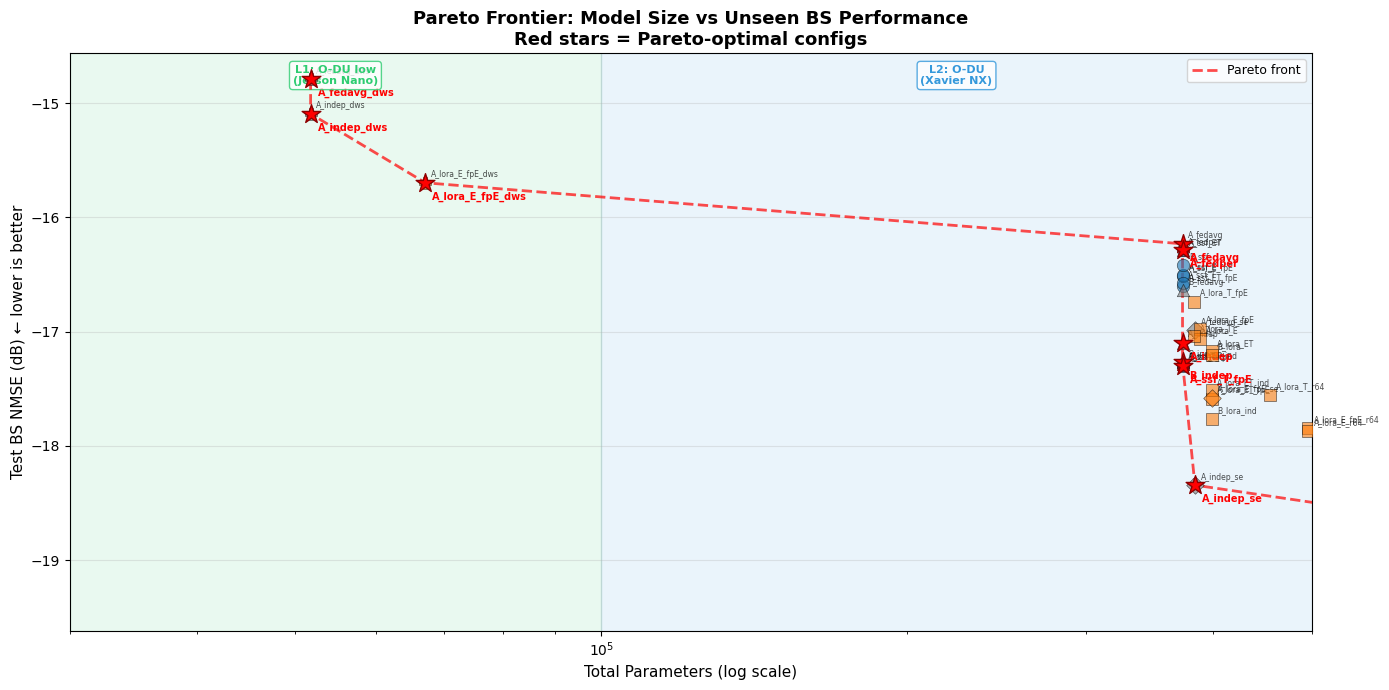


Pareto-optimal configs (best test BS for given param budget):
  A_fedavg_dws                51,778 params  test=-14.79 dB  [L1: O-DU (Jetson Nano)]
  A_indep_dws                 51,778 params  test=-15.09 dB  [L1: O-DU (Jetson Nano)]
  A_lora_E_fpE_dws            67,138 params  test=-15.70 dB  [L1: O-DU (Jetson Nano)]
  A_fedavg                   373,058 params  test=-16.23 dB  [L2: O-DU (Xavier NX)]
  A_fedper                   373,058 params  test=-16.29 dB  [L2: O-DU (Xavier NX)]
  A_indep                    373,058 params  test=-17.10 dB  [L2: O-DU (Xavier NX)]
  B_indep                    373,058 params  test=-17.27 dB  [L2: O-DU (Xavier NX)]
  A_ssf_T_fpE                373,314 params  test=-17.30 dB  [L2: O-DU (Xavier NX)]
  A_indep_se                 383,698 params  test=-18.34 dB  [L2: O-DU (Xavier NX)]
  A_indep_c128              1,483,394 params  test=-19.11 dB  [L3: O-DU/near-RT RIC (Orin)]
  A_lora_E_fpE_c128         1,729,154 params  test=-19.37 dB  [L3: O-DU/near-RT RIC

In [14]:
# Pareto frontier: params vs test BS performance
# Highlight configs that are Pareto-optimal (best test BS for given param budget)
if results:
    items = [(name, r['n_total_params'], r['avg_test_bs']) for name, r in results.items()]
    items.sort(key=lambda x: x[1])  # sort by params

    # Find Pareto front (lower params, lower NMSE = better)
    pareto = []
    best_so_far = 0  # higher (worse) than any result
    for name, params, test_db in items:
        if test_db < best_so_far or not pareto:
            pareto.append((name, params, test_db))
            best_so_far = test_db

    fig, ax = plt.subplots(figsize=(14, 7))

    # Device tier backgrounds
    tier_bounds = [
        (30_000, 100_000, 'L1: O-DU low\n(Jetson Nano)', '#2ecc71'),
        (100_000, 500_000, 'L2: O-DU\n(Xavier NX)', '#3498db'),
    ]
    for xmin, xmax, label, color in tier_bounds:
        ax.axvspan(xmin, xmax, alpha=0.1, color=color, zorder=0)

    # All points
    for name, r in results.items():
        color = 'C0' if 'ssf' in name else 'C1' if 'lora' in name else 'C7'
        marker = 'D' if '_se' in name else 'P' if '_dws' in name else ('o' if 'ssf' in name else 's' if 'lora' in name else '^')
        ax.scatter(r['n_total_params'], r['avg_test_bs'], c=color, marker=marker,
                  s=80, edgecolors='black', linewidth=0.5, zorder=5, alpha=0.6)
        ax.annotate(name, (r['n_total_params'], r['avg_test_bs']),
                   textcoords='offset points', xytext=(4, 4), fontsize=5.5, alpha=0.7)

    # Pareto front
    pareto_params = [p for _, p, _ in pareto]
    pareto_vals = [v for _, _, v in pareto]
    ax.plot(pareto_params, pareto_vals, 'r--', linewidth=2, alpha=0.7, zorder=4, label='Pareto front')
    for name, params, val in pareto:
        ax.scatter(params, val, c='red', marker='*', s=200, zorder=6, edgecolors='darkred')
        ax.annotate(name, (params, val), textcoords='offset points', xytext=(5, -12),
                   fontsize=7, fontweight='bold', color='red')

    # Tier labels
    ymin, ymax = ax.get_ylim()
    for xmin, xmax, label, color in tier_bounds:
        mid = np.sqrt(xmin * xmax)
        ax.text(mid, ymax - (ymax - ymin) * 0.02, label, ha='center', va='top',
                fontsize=8, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=color))

    ax.set_xscale('log')
    ax.set_xlabel('Total Parameters (log scale)', fontsize=11)
    ax.set_ylabel('Test BS NMSE (dB) ← lower is better', fontsize=11)
    ax.set_title('Pareto Frontier: Model Size vs Unseen BS Performance\n'
                 'Red stars = Pareto-optimal configs', fontsize=13, fontweight='bold')
    ax.set_xlim(30_000, 500_000)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('\nPareto-optimal configs (best test BS for given param budget):')
    for name, params, test_db in pareto:
        tier, device, _, _ = get_tier(params)
        print(f'  {name:<25} {params:>8,} params  test={test_db:.2f} dB  [{tier}: {device}]')